In [17]:
# essential libraries for numerical operations and data manipulation
import numpy as np
import pandas as pd
# visualization libraries for plotting and charts
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# tools for data preprocessing and model evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# selection of ML models for experimentation
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression


In [18]:
df=pd.read_csv("Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [19]:
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [21]:
df.isnull().sum()


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [22]:
# Identify any duplicate rows in the dataset
df.duplicated().sum()

0

In [23]:
# Remove duplicate rows from the dataset to ensure data quality
df = df.drop_duplicates()

In [24]:
# Get descriptive statistics of the dataset's numerical features
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [25]:
# Print the number of rows and columns in the dataset
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset contains 2200 rows and 8 columns.


In [26]:
# List and count the unique crop labels in the target column
unique_crops = df['label'].unique()
print(f"Unique crop labels: {unique_crops}")
print(f"Total unique crops: {len(unique_crops)}")

Unique crop labels: ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']
Total unique crops: 22


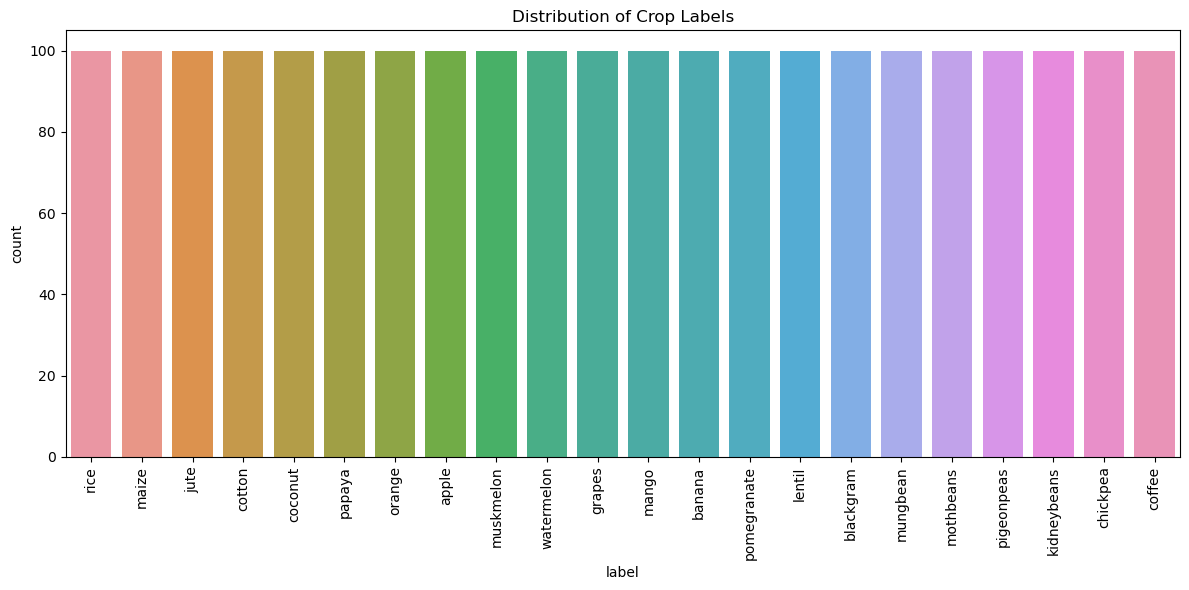

In [27]:
# Plot the distribution of crop labels to assess class balance
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Distribution of Crop Labels')
plt.tight_layout()
plt.show()

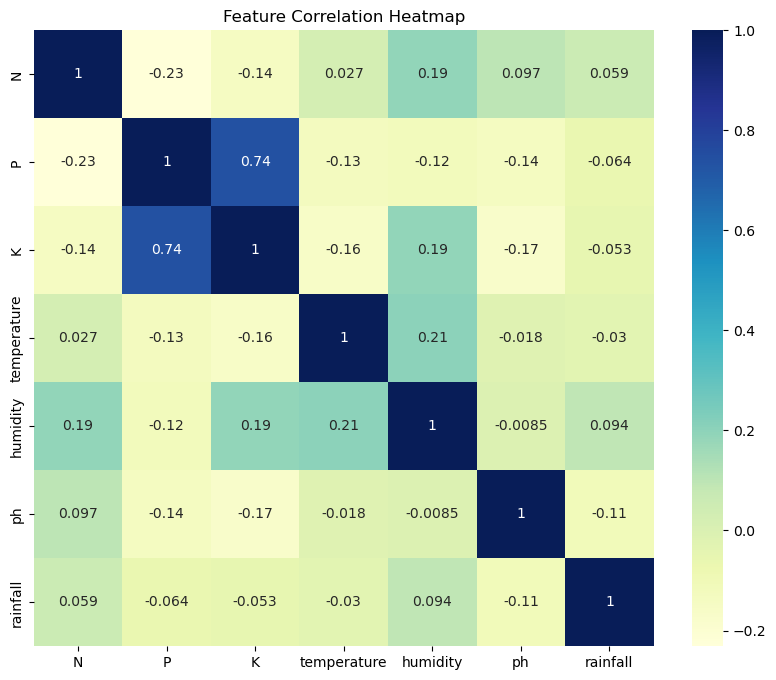

In [28]:
# Display a heatmap to visualize correlation among numerical features (excluding non-numeric columns)
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns='label').corr(), annot=True, cmap='YlGnBu')
plt.title('Feature Correlation Heatmap')
plt.show()

In [29]:
# Compile key dataset statistics into a summary dictionary
summary = {
    "Shape": df.shape,
    "Missing Values": df.isnull().sum().sum(),
    "Duplicates": df.duplicated().sum(),
    "Unique Labels": df['label'].nunique(),
    "Labels": list(df['label'].unique())
}
summary

{'Shape': (2200, 8),
 'Missing Values': 0,
 'Duplicates': 0,
 'Unique Labels': 22,
 'Labels': ['rice',
  'maize',
  'chickpea',
  'kidneybeans',
  'pigeonpeas',
  'mothbeans',
  'mungbean',
  'blackgram',
  'lentil',
  'pomegranate',
  'banana',
  'mango',
  'grapes',
  'watermelon',
  'muskmelon',
  'apple',
  'orange',
  'papaya',
  'coconut',
  'cotton',
  'jute',
  'coffee']}

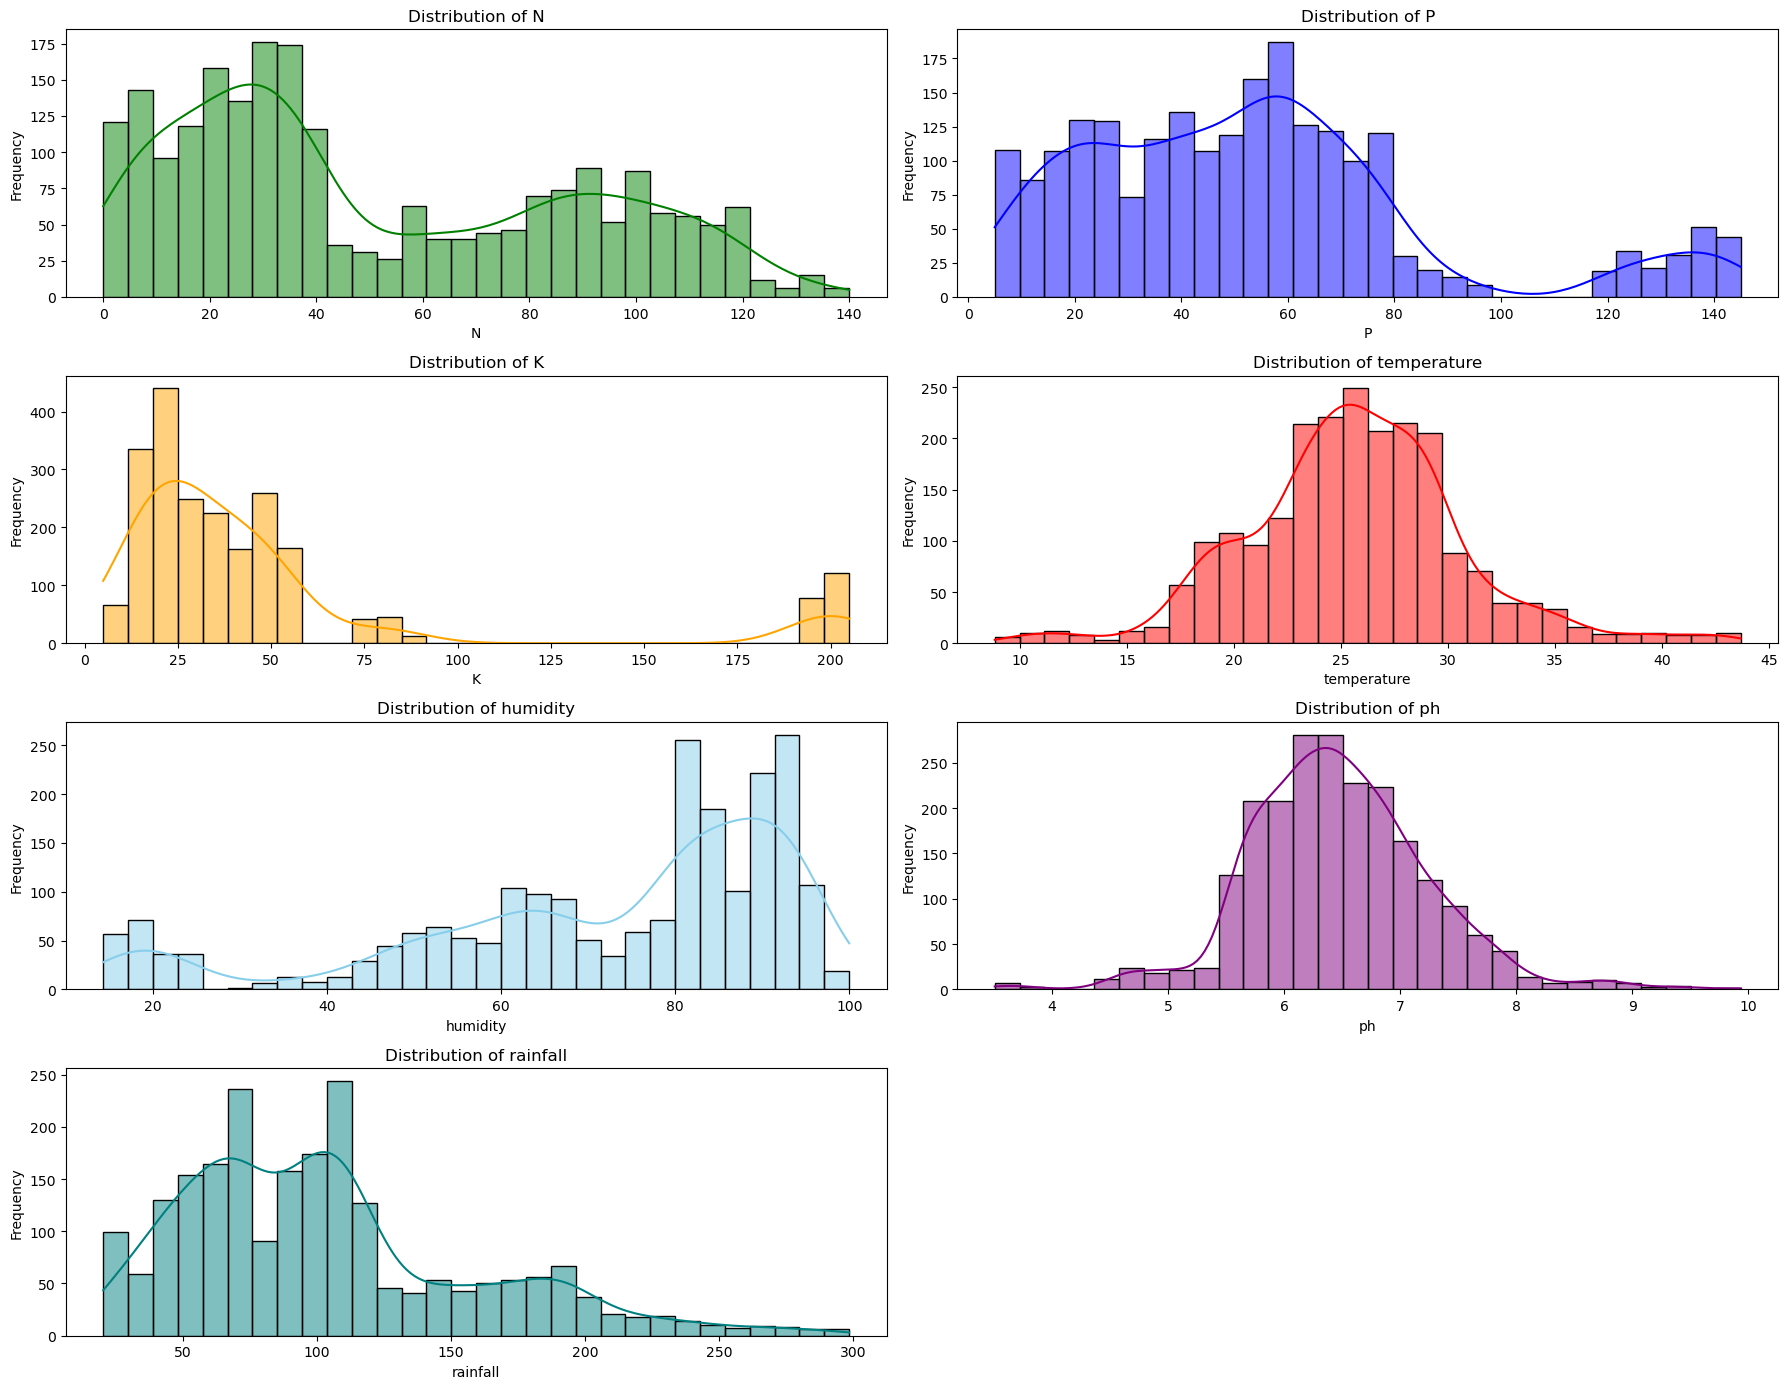

In [30]:
# Plot the distributions of all numerical features using subplots

features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
colors = ['green', 'blue', 'orange', 'red', 'skyblue', 'purple', 'teal']

plt.figure(figsize=(18, 14))
for i, feature in enumerate(features):
    plt.subplot(4, 2, i+1)
    sns.histplot(df[feature], kde=True, bins=30, color=colors[i])
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

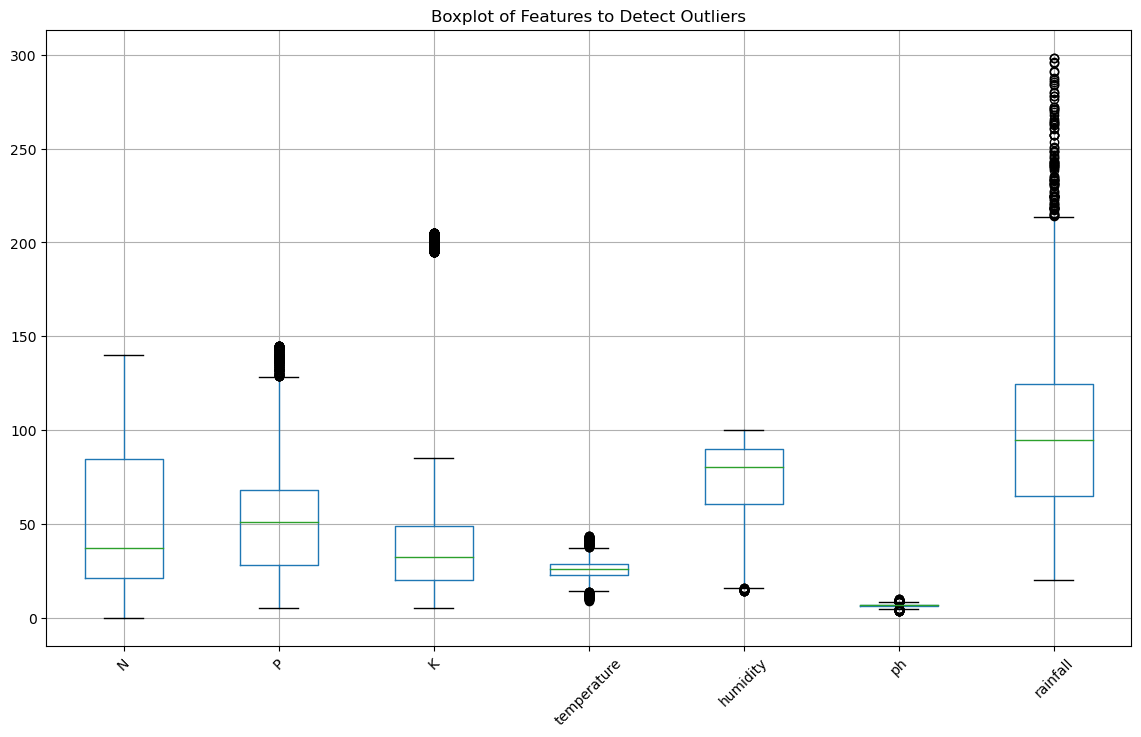

In [31]:
# Use boxplots to detect outliers for each numeric feature
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
plt.figure(figsize=(14,8))
df[features].boxplot(rot=45)
plt.title('Boxplot of Features to Detect Outliers')
plt.show()

c:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


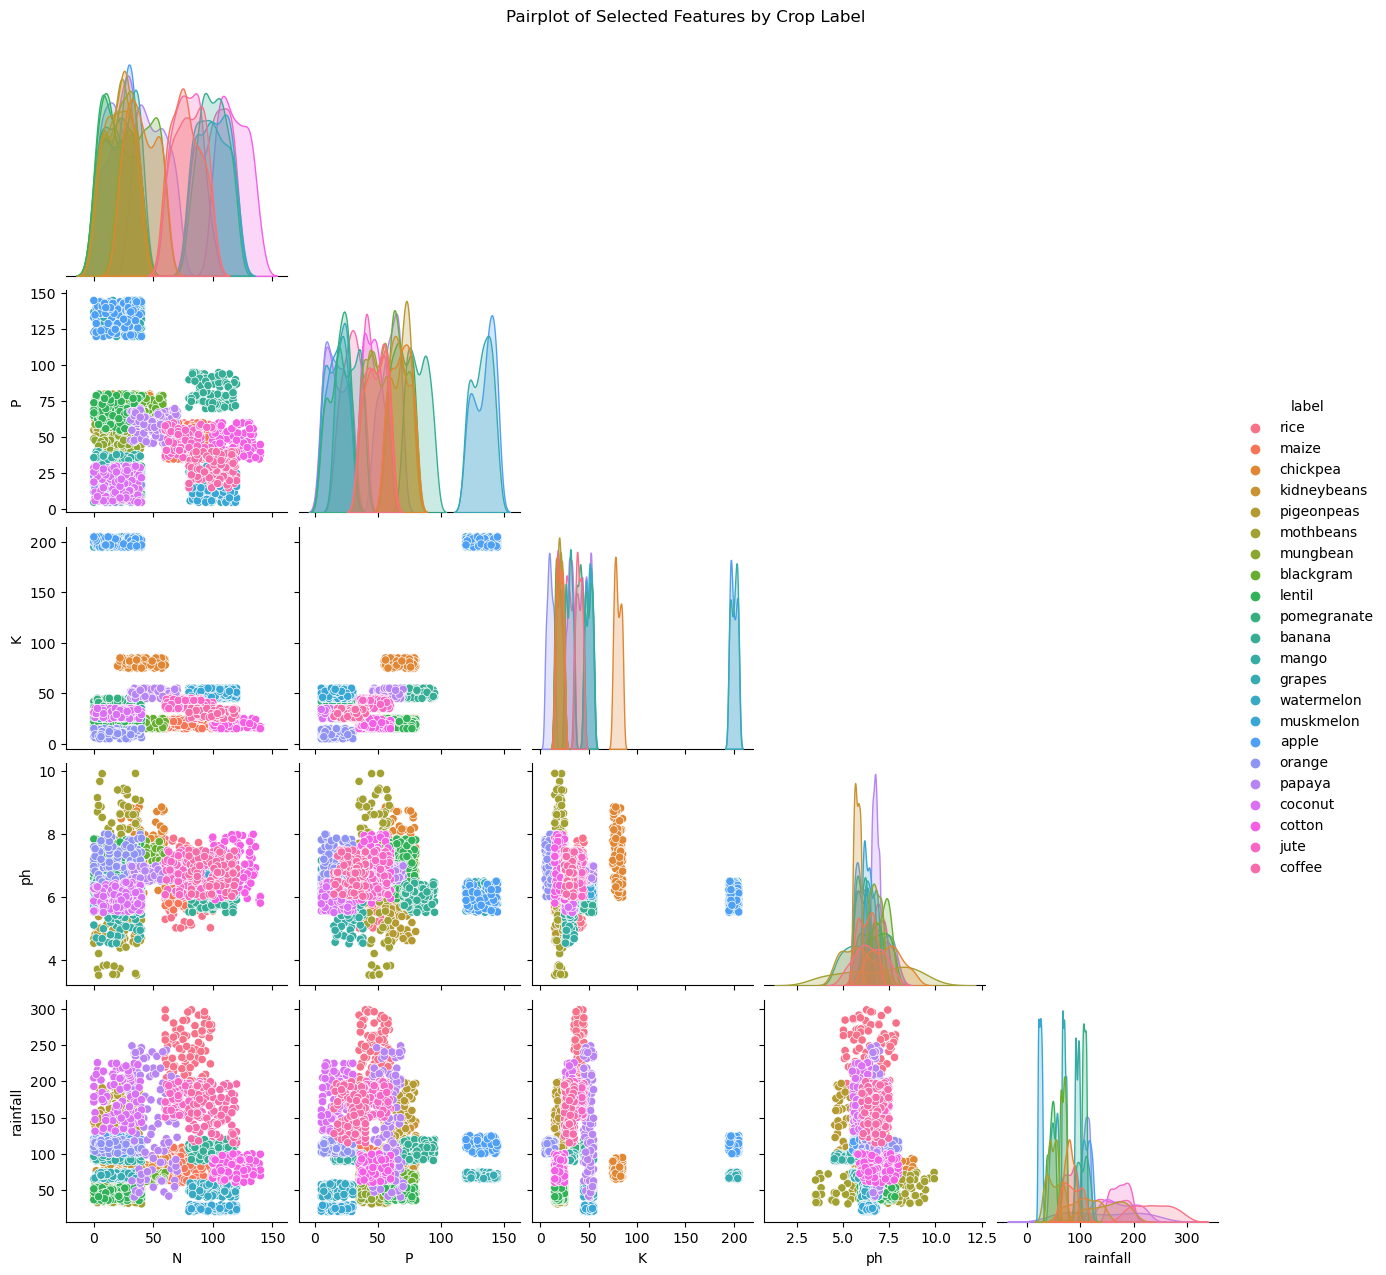

In [32]:
# Create a pairplot of key features with hue based on crop labels
sns.pairplot(df[['N', 'P', 'K', 'ph', 'rainfall', 'label']], hue='label', diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Selected Features by Crop Label', y=1.02)
plt.show()

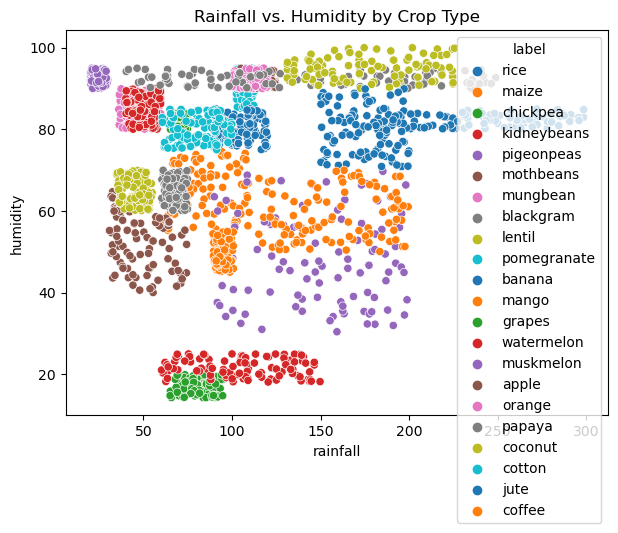

In [33]:
# Scatter plot between rainfall and humidity
plt.figure(figsize=(7,5))
sns.scatterplot(x='rainfall', y='humidity', hue='label', data=df, palette='tab10')
plt.title('Rainfall vs. Humidity by Crop Type')
plt.show()

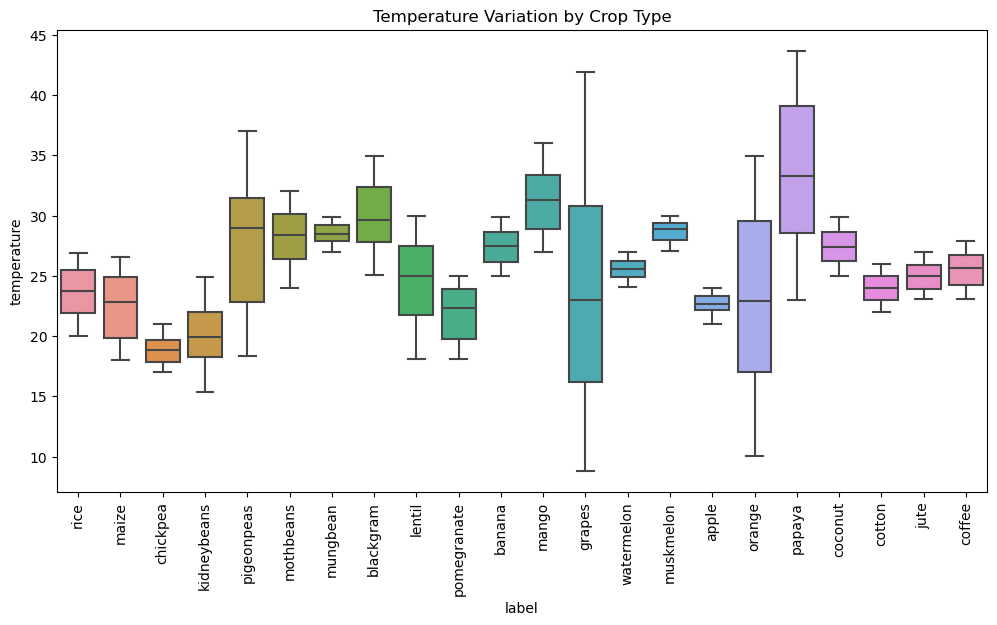

In [34]:
# Boxplot of temperature values for different crop types
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='temperature', data=df)
plt.xticks(rotation=90)
plt.title('Temperature Variation by Crop Type')
plt.show()

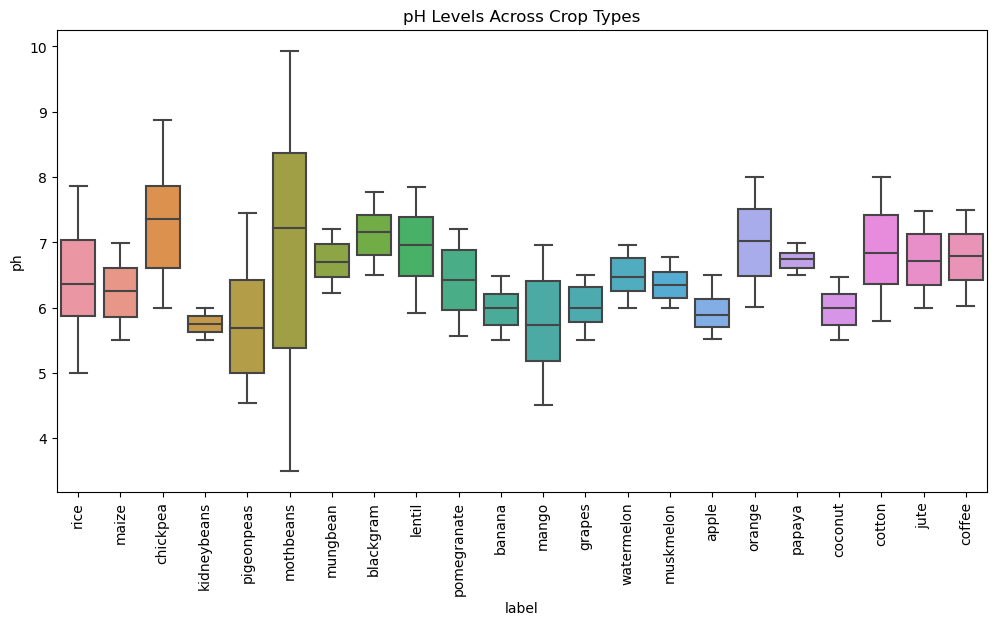

In [35]:
# Boxplot of pH values across different crops
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='ph', data=df)
plt.xticks(rotation=90)
plt.title('pH Levels Across Crop Types')
plt.show()

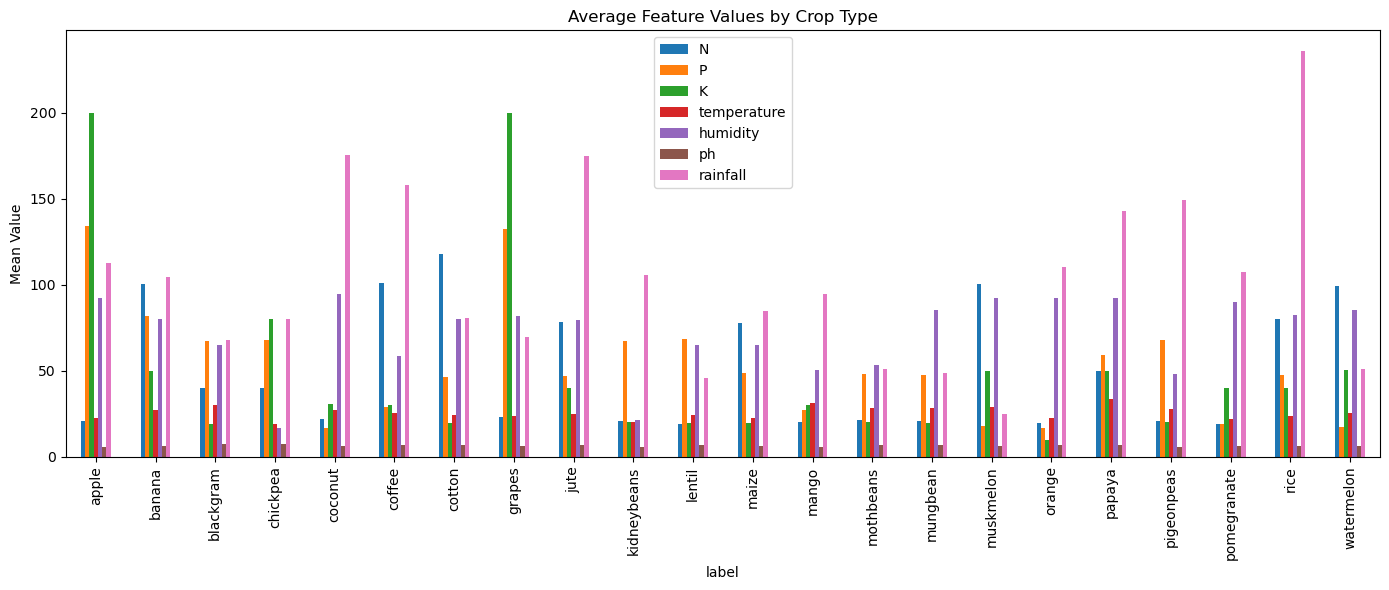

In [36]:
# Group by crop label and plot the mean values of features
grouped = df.groupby('label').mean().reset_index()
grouped.set_index('label').plot(kind='bar', figsize=(14,6))
plt.title('Average Feature Values by Crop Type')
plt.ylabel('Mean Value')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

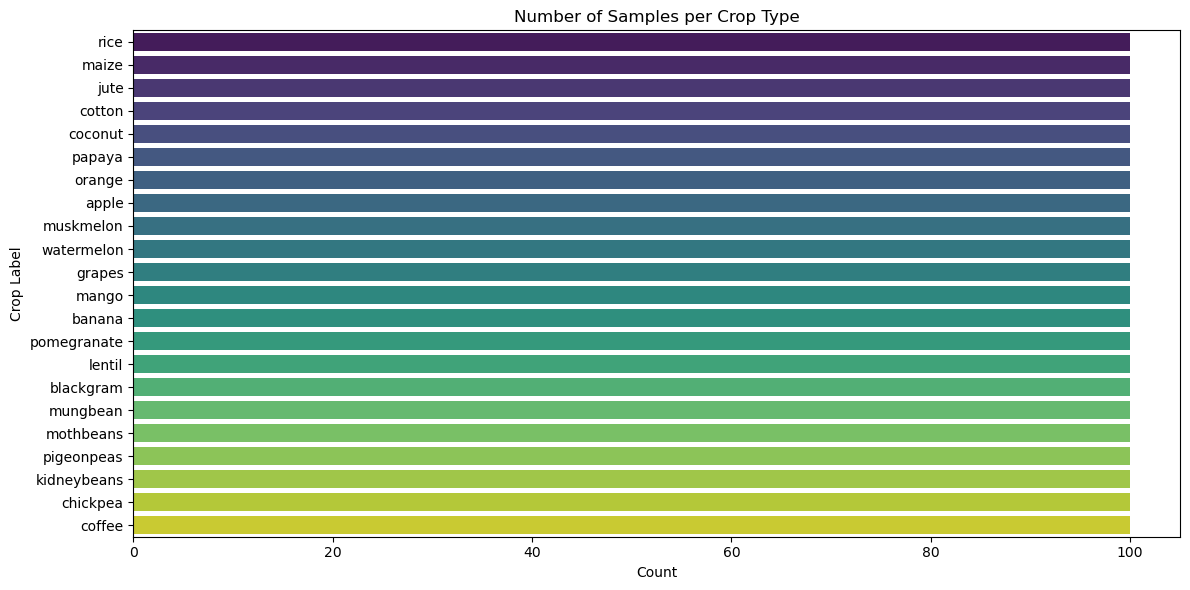

In [37]:
# Plot count of samples available for each crop type
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Number of Samples per Crop Type')
plt.xlabel('Count')
plt.ylabel('Crop Label')
plt.tight_layout()
plt.show()

In [38]:
# Print the min and max values for each numerical feature
for col in df.select_dtypes(include=np.number).columns:
    print(f"{col}: Min = {df[col].min()}, Max = {df[col].max()}")

N: Min = 0, Max = 140
P: Min = 5, Max = 145
K: Min = 5, Max = 205
temperature: Min = 8.825674745, Max = 43.67549305
humidity: Min = 14.25803981, Max = 99.98187601
ph: Min = 3.504752314, Max = 9.93509073
rainfall: Min = 20.21126747, Max = 298.5601175
